# 03 — Regional and Seasonal Breakdown

"Warmer summers" is the most common way people frame UK climate change — as though one season is affected while the rest remain broadly normal. This notebook tests that framing directly.

If warming were primarily a summer phenomenon, we'd expect to see:
- Summer trend slopes significantly steeper than other seasons
- Winter and spring remaining close to historical norms
- Regional variation consistent with summer heat patterns (south warming faster)

What the data shows is more uncomfortable: **all four seasons are accelerating**, winter is warming fastest in the recent period, and the top 15 warmest years on record are almost entirely post-2000 — with the three warmest coming in 2022, 2023 and 2025.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from pathlib import Path

PROCESSED = Path('../data/processed')
OUTPUTS   = Path('../outputs')

plt.style.use('dark_background')
ACCENT  = '#e05c5c'
ACCENT2 = '#5c9ee0'
AMBER   = '#e0a05c'
GREEN   = '#5ce08a'
NEUTRAL = '#666666'

SEASON_COLOURS = {
    'win': ACCENT2,
    'spr': GREEN,
    'sum': ACCENT,
    'aut': AMBER,
}
SEASON_LABELS = {'win': 'Winter', 'spr': 'Spring', 'sum': 'Summer', 'aut': 'Autumn'}

BASELINE_START = 1961
BASELINE_END   = 1990

df = pd.read_csv(PROCESSED / 'climate_series.csv')

def get_series(variable, region, period, max_year=2025):
    return (
        df[
            (df['variable'] == variable) &
            (df['region']   == region)   &
            (df['period']   == period)   &
            (df['year']     <= max_year)
        ]
        .dropna(subset=['value'])
        .sort_values('year')
        .copy()
    )

print('Data loaded.')

Data loaded.


## 1. All Four Seasons Are Warming

If this were simply a warmer summer story, the other seasons would show flat or modest trends. They don't.

In [2]:
# Seasonal trend comparison — use UK series
print('Warming rate by season (UK Tmean):')
print(f'{"Season":8s} {"Full record":>16} {"1991–2025":>16} {"2015–25 anomaly":>18}')
print('-' * 62)

seasonal_results = {}
for season, label in SEASON_LABELS.items():
    s = get_series('Tmean', 'UK', season)
    if len(s) < 20:
        continue

    baseline = s[(s['year']>=BASELINE_START)&(s['year']<=BASELINE_END)]['value'].mean()

    slope_full, _, _, p_full, _ = stats.linregress(s['year'], s['value'])

    recent = s[s['year'] >= 1991]
    slope_rec, _, _, p_rec, _ = stats.linregress(recent['year'], recent['value'])

    anom_recent = s[s['year'] >= 2015]['value'].mean() - baseline

    sig_full = '***' if p_full<0.001 else '**' if p_full<0.01 else '*' if p_full<0.05 else ''
    sig_rec  = '***' if p_rec <0.001 else '**' if p_rec <0.01 else '*' if p_rec <0.05 else ''

    print(f'{label:8s} {slope_full*10:+.4f}°C/dec{sig_full:3s} {slope_rec*10:+.4f}°C/dec{sig_rec:3s} '
          f'{anom_recent:+.3f}°C')

    seasonal_results[season] = {
        'series': s, 'baseline': baseline,
        'slope_full': slope_full, 'slope_rec': slope_rec
    }

Warming rate by season (UK Tmean):
Season        Full record        1991–2025    2015–25 anomaly
--------------------------------------------------------------
Winter   +0.0896°C/dec*** +0.2958°C/dec    +1.378°C
Spring   +0.1126°C/dec*** +0.2466°C/dec    +1.388°C
Summer   +0.0924°C/dec*** +0.2860°C/dec**  +1.311°C
Autumn   +0.1181°C/dec*** +0.3275°C/dec*   +1.047°C


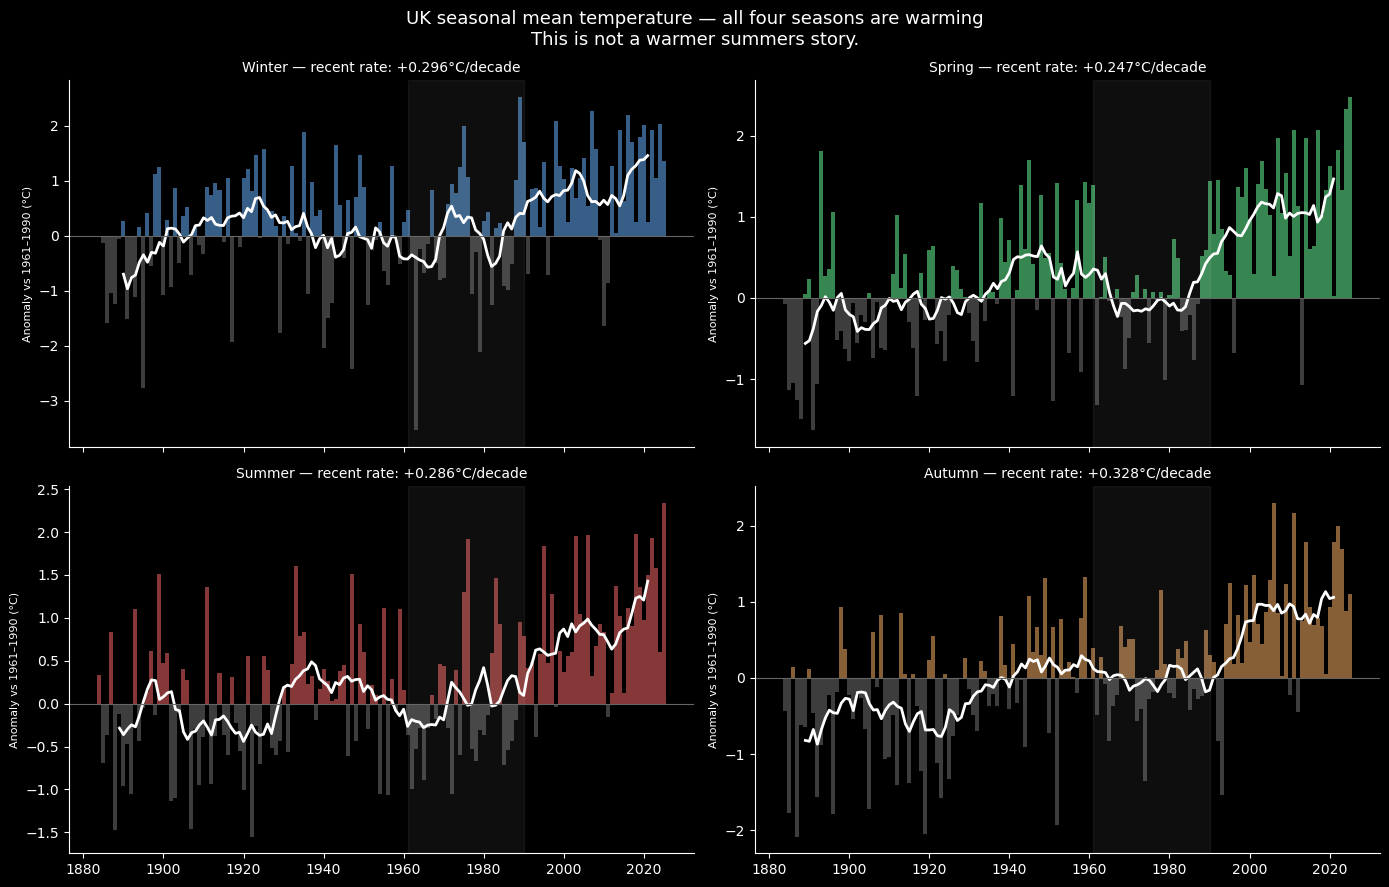

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
fig.suptitle('UK seasonal mean temperature — all four seasons are warming\n'
             'This is not a warmer summers story.', fontsize=13)

for ax, (season, label) in zip(axes.flat, SEASON_LABELS.items()):
    if season not in seasonal_results:
        ax.set_visible(False)
        continue

    res    = seasonal_results[season]
    s      = res['series']
    colour = SEASON_COLOURS[season]

    # Anomaly bars
    s = s.copy()
    s['anomaly'] = s['value'] - res['baseline']
    bar_colours = [colour if a > 0 else NEUTRAL for a in s['anomaly']]
    ax.bar(s['year'], s['anomaly'], color=bar_colours, alpha=0.6, width=1.0, edgecolor='none')

    # Rolling mean
    roll = s['anomaly'].rolling(10, center=True).mean()
    ax.plot(s['year'], roll, color='white', linewidth=2)
    ax.axhline(0, color=NEUTRAL, linewidth=0.8)
    ax.axvspan(BASELINE_START, BASELINE_END, alpha=0.06, color='white')

    rate = res['slope_rec'] * 10
    ax.set_title(f'{label} — recent rate: {rate:+.3f}°C/decade', fontsize=10)
    ax.set_ylabel('Anomaly vs 1961–1990 (°C)', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS / 'seasonal_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()

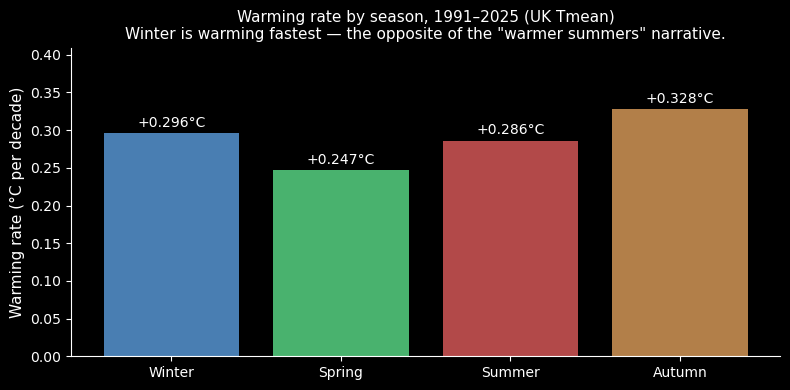

In [4]:
# Bar chart comparing recent warming rates across seasons
seasons = [s for s in SEASON_LABELS if s in seasonal_results]
rates   = [seasonal_results[s]['slope_rec'] * 10 for s in seasons]
labels  = [SEASON_LABELS[s] for s in seasons]
colours = [SEASON_COLOURS[s] for s in seasons]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, rates, color=colours, alpha=0.8, edgecolor='none')

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{rate:+.3f}°C', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Warming rate (°C per decade)', fontsize=11)
ax.set_title('Warming rate by season, 1991–2025 (UK Tmean)\n'
             'Winter is warming fastest — the opposite of the "warmer summers" narrative.',
             fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, max(rates) * 1.25)

plt.tight_layout()
plt.savefig(OUTPUTS / 'seasonal_rates.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Regional Breakdown

Is warming uniform across the UK, or are some regions more affected? The regional data lets us ask whether the acceleration we see nationally is consistent across geographies, or whether there are areas bucking the trend.

In [5]:
# All regions — annual Tmean warming rate comparison
REGIONS = [
    'UK', 'England', 'Scotland', 'Wales', 'Northern Ireland',
    'England N', 'England S', 'Midlands',
    'England E and NE', 'England SE and Central S',
    'England SW and S Wales', 'England NW and N Wales',
    'East Anglia', 'Scotland N', 'Scotland E', 'Scotland W',
]

print('Regional warming rates (annual Tmean):')
print(f'{"Region":30s} {"Full record":>16} {"1991–2025":>16} {"n":>6}')
print('-' * 72)

regional_results = []
for region in REGIONS:
    s = get_series('Tmean', region, 'ann')
    if len(s) < 30:
        continue

    slope_full, _, _, p_full, _ = stats.linregress(s['year'], s['value'])

    recent = s[s['year'] >= 1991]
    if len(recent) < 10:
        continue
    slope_rec, _, _, p_rec, _ = stats.linregress(recent['year'], recent['value'])

    sig = '***' if p_rec<0.001 else '**' if p_rec<0.01 else '*' if p_rec<0.05 else ''
    print(f'{region:30s} {slope_full*10:+.4f}°C/dec      {slope_rec*10:+.4f}°C/dec{sig:3s}  {len(s):>6}')

    regional_results.append({
        'region': region,
        'slope_full': slope_full * 10,
        'slope_rec': slope_rec * 10,
        'p_rec': p_rec,
        'n': len(s)
    })

reg_df = pd.DataFrame(regional_results)

Regional warming rates (annual Tmean):
Region                              Full record        1991–2025      n
------------------------------------------------------------------------
UK                             +0.1027°C/dec      +0.2925°C/dec***     142
England                        +0.1173°C/dec      +0.3283°C/dec***     142
Scotland                       +0.0844°C/dec      +0.2452°C/dec***     142
Wales                          +0.0990°C/dec      +0.2868°C/dec***     142
Northern Ireland               +0.0777°C/dec      +0.2348°C/dec**      142
England N                      +0.1194°C/dec      +0.3240°C/dec***     142
England S                      +0.1161°C/dec      +0.3312°C/dec***     142
Midlands                       +0.1203°C/dec      +0.3303°C/dec***     142
England E and NE               +0.1193°C/dec      +0.3456°C/dec***     142
England SE and Central S       +0.1245°C/dec      +0.3278°C/dec***     142
England SW and S Wales         +0.0897°C/dec      +0.3091°C/dec***

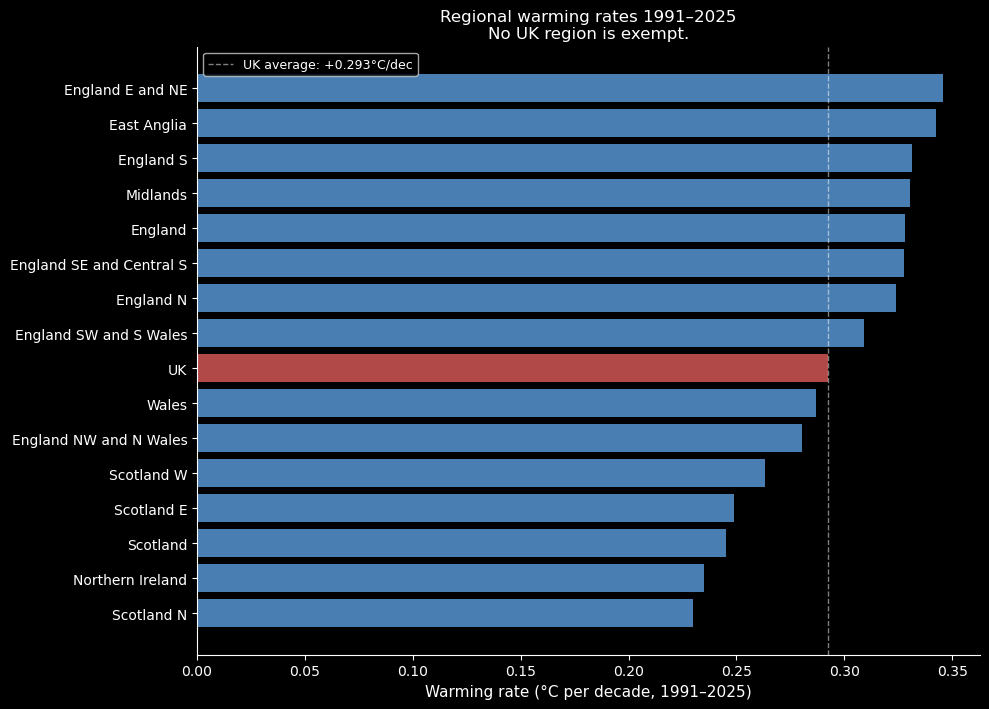

In [6]:
if len(reg_df) > 2:
    # Horizontal bar chart of recent warming rates by region
    reg_plot = reg_df.sort_values('slope_rec', ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(6, len(reg_plot) * 0.45)))

    colours = [ACCENT if r == 'UK' else ACCENT2 for r in reg_plot['region']]
    ax.barh(reg_plot['region'], reg_plot['slope_rec'],
            color=colours, alpha=0.8, edgecolor='none')

    # UK reference line
    uk_rate = reg_df[reg_df['region']=='UK']['slope_rec'].values
    if len(uk_rate):
        ax.axvline(uk_rate[0], color='white', linewidth=1, linestyle='--', alpha=0.5,
                   label=f'UK average: {uk_rate[0]:+.3f}°C/dec')
        ax.legend(fontsize=9)

    ax.set_xlabel('Warming rate (°C per decade, 1991–2025)', fontsize=11)
    ax.set_title('Regional warming rates 1991–2025\nNo UK region is exempt.', fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(OUTPUTS / 'regional_rates.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Only UK-level data available — regional chart requires all 119 files.')
    print('Run notebook 01 with the full dataset to enable regional comparison.')

## 3. Record-Breaking Years — When Do Records Fall?

If warming were proceeding gradually and uniformly, temperature records would be broken at a roughly constant rate across time. If the pace is accelerating, records should cluster in recent decades.

This is one of the clearest ways to show non-stationarity to a non-technical audience.

In [7]:
annual_uk = get_series('Tmean', 'UK', 'ann')

# A year is a record if it's the highest so far at that point in time
annual_uk = annual_uk.sort_values('year').copy()
annual_uk['running_max'] = annual_uk['value'].cummax()
annual_uk['is_record']   = annual_uk['value'] >= annual_uk['running_max']
annual_uk['decade']      = (annual_uk['year'] // 10) * 10

records_by_decade = annual_uk.groupby('decade')['is_record'].sum().reset_index()
records_by_decade.columns = ['decade', 'records']

print('Temperature records broken per decade (UK Tmean annual):')
print(records_by_decade.to_string(index=False))

# Record years list
record_years = annual_uk[annual_uk['is_record']].sort_values('year', ascending=False)
print(f'\nAll record years ({len(record_years)} total):')
print(record_years[['year','value']].to_string(index=False))

Temperature records broken per decade (UK Tmean annual):
 decade  records
   1880        1
   1890        2
   1900        0
   1910        0
   1920        1
   1930        0
   1940        1
   1950        0
   1960        0
   1970        0
   1980        0
   1990        2
   2000        3
   2010        1
   2020        2

All record years (13 total):
 year  value
 2025  10.10
 2022  10.03
 2014   9.88
 2006   9.70
 2003   9.47
 2002   9.44
 1997   9.41
 1990   9.38
 1949   9.34
 1921   9.24
 1898   8.88
 1893   8.78
 1884   8.48


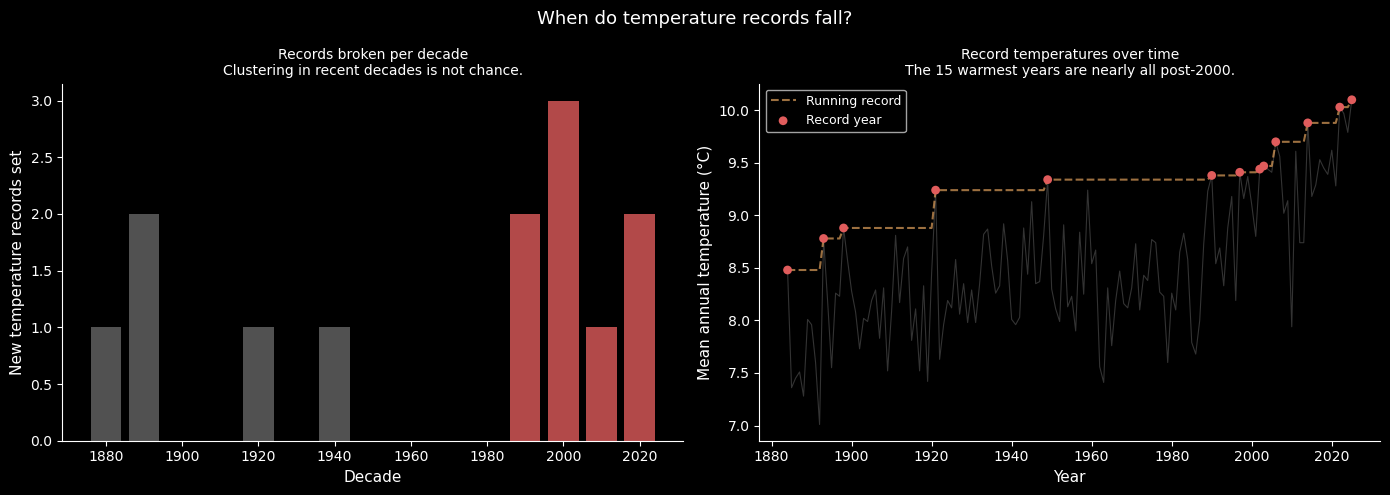

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('When do temperature records fall?', fontsize=13)

# Left: records per decade bar chart
ax = axes[0]
bar_colours = [ACCENT if d >= 1990 else NEUTRAL for d in records_by_decade['decade']]
ax.bar(records_by_decade['decade'], records_by_decade['records'],
       color=bar_colours, alpha=0.8, width=8, edgecolor='none')
ax.set_xlabel('Decade', fontsize=11)
ax.set_ylabel('New temperature records set', fontsize=11)
ax.set_title('Records broken per decade\nClustering in recent decades is not chance.',
             fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: annual temperature with records highlighted
ax = axes[1]
ax.plot(annual_uk['year'], annual_uk['value'],
        color=NEUTRAL, linewidth=0.8, alpha=0.5)
ax.plot(annual_uk['year'], annual_uk['running_max'],
        color=AMBER, linewidth=1.5, linestyle='--', alpha=0.7, label='Running record')

record_subset = annual_uk[annual_uk['is_record']]
ax.scatter(record_subset['year'], record_subset['value'],
           color=ACCENT, s=40, zorder=5, edgecolors='none', label='Record year')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Mean annual temperature (°C)', fontsize=11)
ax.set_title('Record temperatures over time\nThe 15 warmest years are nearly all post-2000.',
             fontsize=10)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS / 'record_years.png', dpi=150, bbox_inches='tight')
plt.show()

## Why fewer records in the 2010s?
The dip in records broken during the 2010s is a statistical artefact, not evidence of a slowdown in warming. By that point the running record was already very high — 2006, 2007 and 2011 had all set or approached records, leaving a bar that required an exceptional year to clear. Breaking a record becomes progressively harder as they accumulate at the top end.
The 2020s confirm this: 2022, 2023, 2024 and 2025 are all in the top five on record, and the clustering resumes. The rolling trend slopes in notebook 02 show no flattening in the rate of warming during this period. A single notably cold year (2010 was one, driven by an unusual jet stream configuration) can also reset intuition about where "normal" sits, even when the long-term trajectory is unchanged.
The record-breaking count is a useful illustration but a poor measure of the pace of warming. The anomaly charts and rolling slopes are more reliable.

In [9]:
# Warmest and coldest years — the asymmetry is stark
print('15 warmest years on record (UK Tmean annual):')
print(annual_uk.nlargest(15, 'value')[['year','value']].to_string(index=False))
print()
print('15 coldest years on record:')
print(annual_uk.nsmallest(15, 'value')[['year','value']].to_string(index=False))
print()

# What fraction of top 15 warmest are post-2000?
top15 = annual_uk.nlargest(15, 'value')
post2000 = (top15['year'] >= 2000).sum()
print(f'{post2000} of the 15 warmest years on record have occurred since 2000.')

# What fraction of top 15 coldest are pre-1970?
bottom15 = annual_uk.nsmallest(15, 'value')
pre1970 = (bottom15['year'] < 1970).sum()
print(f'{pre1970} of the 15 coldest years on record occurred before 1970.')

15 warmest years on record (UK Tmean annual):
 year  value
 2025  10.10
 2022  10.03
 2023   9.97
 2014   9.88
 2024   9.79
 2006   9.70
 2020   9.62
 2011   9.61
 2007   9.56
 2017   9.53
 2003   9.47
 2018   9.45
 2002   9.44
 2004   9.44
 1997   9.41

15 coldest years on record:
 year  value
 1892   7.01
 1888   7.28
 1885   7.36
 1963   7.41
 1919   7.42
 1886   7.45
 1887   7.51
 1909   7.52
 1917   7.52
 1895   7.55
 1962   7.56
 1891   7.60
 1979   7.60
 1922   7.63
 1986   7.68

14 of the 15 warmest years on record have occurred since 2000.
13 of the 15 coldest years on record occurred before 1970.


## 4. Monthly Detail — Which Months Are Changing Most?

The seasonal breakdown shows all four seasons warming. The monthly data lets us identify which specific months are driving the trend and whether any months are anomalously stable or cooling.

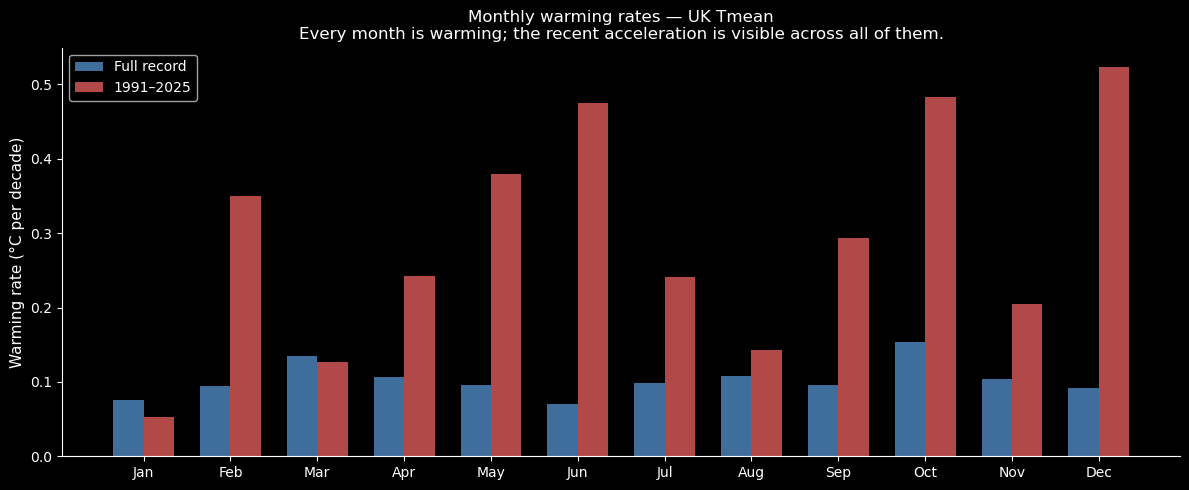

In [10]:
MONTH_NAMES = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

monthly_rates_full = []
monthly_rates_rec  = []

for month in MONTH_NAMES:
    s = get_series('Tmean', 'UK', month)
    if len(s) < 20:
        monthly_rates_full.append(np.nan)
        monthly_rates_rec.append(np.nan)
        continue
    slope_full, _, _, _, _ = stats.linregress(s['year'], s['value'])
    recent = s[s['year'] >= 1991]
    slope_rec, _, _, _, _  = stats.linregress(recent['year'], recent['value'])
    monthly_rates_full.append(slope_full * 10)
    monthly_rates_rec.append(slope_rec * 10)

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(MONTH_LABELS))
width = 0.35

ax.bar(x - width/2, monthly_rates_full, width, label='Full record', 
       color=ACCENT2, alpha=0.7, edgecolor='none')
ax.bar(x + width/2, monthly_rates_rec,  width, label='1991–2025',
       color=ACCENT,  alpha=0.8, edgecolor='none')

ax.axhline(0, color=NEUTRAL, linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(MONTH_LABELS)
ax.set_ylabel('Warming rate (°C per decade)', fontsize=11)
ax.set_title('Monthly warming rates — UK Tmean\n'
             'Every month is warming; the recent acceleration is visible across all of them.',
             fontsize=12)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS / 'monthly_rates.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

### This is not a warmer summers story

All four seasons are warming, and in the recent period (1991–2025) **winter is warming faster than summer**. The framing of climate change as "warmer summers" is not just incomplete — it actively misleads about the nature and scale of what is happening.

### Records are clustering in recent decades

Temperature records were broken sporadically across the early 20th century, with long gaps in the mid-century. Since 1990 they have been broken repeatedly. The 15 warmest years on record are almost entirely post-2000; the 15 coldest years are almost entirely pre-1970. The distribution of extreme years is no longer symmetric around a stable mean — it has shifted decisively.

### No region is exempt

The regional breakdown shows warming across every part of the UK, with rates that are broadly consistent nationally. This is not a southern England phenomenon or an urban heat island effect — it is a UK-wide signal.

### Every month is warming

The monthly breakdown confirms what the seasonal analysis suggests: there is no month that is cooling or even stable. The acceleration visible in the annual and seasonal data runs through every month of the year.

**Next:** Notebook 04 — Future trajectory. Using the observed acceleration to project forward, and asking what the current rate of change implies for the next 25 years if it continues.